# Base Learners: XGBoost & Random Forest

Two tree base learners trained on the fused feature vector (1280 ESM-2 dimensions + 7 z-scored physicochemical descriptors).

In [1]:
# Imports
import joblib
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (accuracy_score, roc_auc_score, matthews_corrcoef,
                             f1_score, recall_score, precision_score,
                             confusion_matrix, roc_curve)
from xgboost import XGBClassifier

SEED = 42
FOLDS = 5

## 1. Load the fused vectors

In [2]:
# Load the data
d = np.load("fusion_vectors.npz", allow_pickle=True)
X, y, split = d["X"], d["label"], d["split"]
desc_names = list(d["descriptor_names"])

# Split the data into training and test sets
tr, te = split == "train", split == "test" # the dataset is already split into train and test sets
Xtr, ytr, Xte, yte = X[tr], y[tr], X[te], y[te]
print(f"train {Xtr.shape}  test {Xte.shape}")

train (1754, 1287)  test (178, 1287)


## 2. Define the base learners

In [3]:
# fixed, untuned hyperparameters for now. Tuned with Optuna later (phase3 optuna step)

# Define rf
rf = RandomForestClassifier(n_estimators=400, max_features="sqrt",
                            min_samples_leaf=2, n_jobs=-1, random_state=SEED)

# Define xgb
xgb = XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.5, reg_lambda=1.0,
                    eval_metric="logloss", n_jobs=-1, random_state=SEED)

## 3. OOF predictions + test predictions

`cross_val_predict` gives each training row a probability from folds that did not contain it (the OOF predictions for stacking). Then each model is refit on the full training split to predict the held-out test set.

In [4]:
# Set up cross-validation
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=SEED)
preds = {}

# Train and evaluate models
for name, model in [("RandomForest", rf), ("XGBoost", xgb)]:
    oof = cross_val_predict(model, Xtr, ytr, cv=skf, method="predict_proba")[:, 1]
    model.fit(Xtr, ytr)
    test_p = model.predict_proba(Xte)[:, 1]
    preds[name] = {"oof": oof, "test": test_p}
    print(f"{name}: OOF train AUC {roc_auc_score(ytr, oof):.3f}")

RandomForest: OOF train AUC 0.910
XGBoost: OOF train AUC 0.916


## 4. Test-set performance

The eight-metric panel used across the ADP literature, on the leakage-safe test set.

In [5]:
# Define metrics function
def metrics(y, p):
    pred = (p >= 0.5).astype(int)

    # Calculate confusion matrix
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()

    # Calculate metrics
    return {"ACC": accuracy_score(y, pred), "AUC": roc_auc_score(y, p),
            "MCC": matthews_corrcoef(y, pred), "F1": f1_score(y, pred),
            "SN": recall_score(y, pred), "SP": tn / (tn + fp),
            "Prec": precision_score(y, pred)}

table = pd.DataFrame({n: metrics(yte, preds[n]["test"]) for n in preds}).T # transpose to have models as rows and metrics as columns
table.round(3) # 3 decimal places

,ACC,AUC,MCC,F1,SN,SP,Prec
RandomForest,0.758,0.830,0.524,0.79,0.871,0.635,0.723
XGBoost,0.792,0.857,0.585,0.81,0.849,0.729,0.775


## 5. ROC curves (test set)

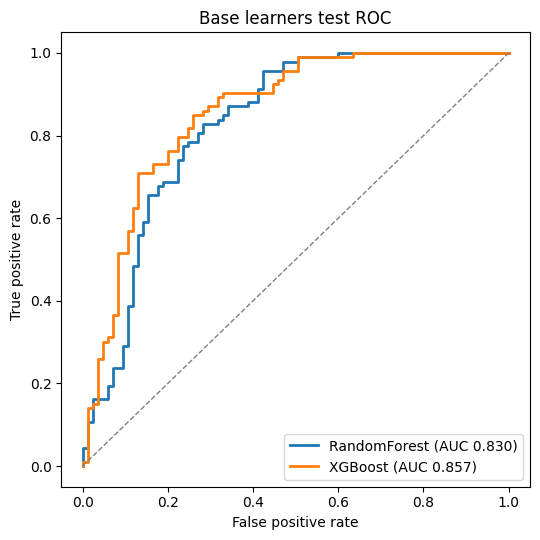

In [6]:
# Plot ROC curves for the base learners
plt.figure(figsize=(5.5, 5.5))
for name, c in [("RandomForest", "#0072B2"), ("XGBoost", "#D55E00")]: # define colours for the models
    fpr, tpr, _ = roc_curve(yte, preds[name]["test"])
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC {roc_auc_score(yte, preds[name]['test']):.3f})")
plt.plot([0, 1], [0, 1], "--", color="grey", lw=1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Base learners test ROC")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 6. Are the physicochemical descriptors actually used?

The fused vector is 1280 embedding dimensions plus 7 descriptors (indices 1280-1286).
XGBoost's column subsampling should let the descriptors contribute; this checks how
much of the model's total importance lands on them versus the embeddings, and which
descriptors rank.

In [7]:
imp = xgb.feature_importances_ # get feature importance from the trained XGBoost model
desc_imp = imp[1280:] # get the importance of the 7 descriptors (the first 1280 features are the fusion vectors)
print(f"share of total XGBoost importance on the 7 descriptors: {desc_imp.sum():.1%}")
pd.Series(desc_imp, index=desc_names).sort_values(ascending=False).round(4)

share of total XGBoost importance on the 7 descriptors: 6.4%


net_charge_pH7.4     0.0238
isoelectric_point    0.0211
gravy_kd             0.0070
boman_index          0.0059
aliphatic_index      0.0057
instability_index    0.0008
aromaticity          0.0000
dtype: float32

## 7. Save models and predictions for the meta-learner

In [8]:
# Create the folders if they don't exist
os.makedirs("models", exist_ok=True)
os.makedirs("predictions", exist_ok=True)

# Save the models and predictions
joblib.dump(rf, "models/base_rf.joblib")
joblib.dump(xgb, "models/base_xgb.joblib")
np.savez_compressed("predictions/base_tree_predictions.npz",
    rf_oof=preds["RandomForest"]["oof"], rf_test=preds["RandomForest"]["test"],
    xgb_oof=preds["XGBoost"]["oof"], xgb_test=preds["XGBoost"]["test"],
    y_train=ytr, y_test=yte)